In [1]:
import torch
import torch.nn as nn
import torchvision.models as models

class MultiScaleDilatedEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        
        # 1. Load STANDARD ResNet18 without the built-in dilation argument
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        resnet = models.resnet18(weights=weights)
        
        # 2. Modify for Grayscale CT Scans
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        if pretrained:
            self.conv1.weight.data = resnet.conv1.weight.data.mean(dim=1, keepdim=True)
            
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        
        # 3. Extract the layers
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        # 4. The Custom Fix: Manually apply dilation to Layer 3 and 4
        # This prevents the image from shrinking while preserving pretrained weights!
        self._apply_dilation(self.layer3, dilation=2)
        self._apply_dilation(self.layer4, dilation=4)

    def _apply_dilation(self, layer, dilation):
        """Iterates through a ResNet BasicBlock and manually injects dilation."""
        for m in layer.modules():
            if isinstance(m, nn.Conv2d):
                # If it's a standard 3x3 convolution, add dilation and remove the stride
                if m.kernel_size == (3, 3):
                    m.stride = (1, 1)
                    m.padding = (dilation, dilation)
                    m.dilation = (dilation, dilation)
                # If it's the 1x1 downsampling convolution in the residual connection, just remove the stride
                elif m.kernel_size == (1, 1):
                    m.stride = (1, 1)

    def forward(self, x):
        features = []
        
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x1 = self.layer1(x)
        features.append(x1)
        
        x2 = self.layer2(x1)
        features.append(x2)
        
        x3 = self.layer3(x2)
        features.append(x3)
        
        x4 = self.layer4(x3)
        features.append(x4)
        
        return features

# --- Quick Test ---
if __name__ == "__main__":
    # Create a dummy batch of 2 grayscale images, 256x256
    dummy_input = torch.randn(2, 1, 256, 256) 
    
    encoder = MultiScaleDilatedEncoder(pretrained=True)
    outputs = encoder(dummy_input)
    
    print("Patched Encoder Output Feature Map Shapes:")
    for i, out in enumerate(outputs):
        print(f"Layer {i+1}: {out.shape} -> Channels: {out.shape[1]}, Resolution: {out.shape[2]}x{out.shape[3]}")

Patched Encoder Output Feature Map Shapes:
Layer 1: torch.Size([2, 64, 64, 64]) -> Channels: 64, Resolution: 64x64
Layer 2: torch.Size([2, 128, 32, 32]) -> Channels: 128, Resolution: 32x32
Layer 3: torch.Size([2, 256, 32, 32]) -> Channels: 256, Resolution: 32x32
Layer 4: torch.Size([2, 512, 32, 32]) -> Channels: 512, Resolution: 32x32


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        # MLP shared by both AvgPool and MaxPool
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_pool = self.mlp(F.adaptive_avg_pool2d(x, 1).view(b, c))
        max_pool = self.mlp(F.adaptive_max_pool2d(x, 1).view(b, c))
        # Add the two pooled features and apply sigmoid
        return torch.sigmoid(avg_pool + max_pool).view(b, c, 1, 1)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        # Standard spatial attention uses a 7x7 conv to look at local pixel neighborhoods
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        # Concatenate average and max pooling along the channel dimension
        x_cat = torch.cat([avg_out, max_out], dim=1)
        return torch.sigmoid(self.conv(x_cat))

class FrequencyAttention(nn.Module):
    """
    The novel FFT-based feature attention.
    Converts features to the frequency domain, dynamically weights the frequencies
    to enhance high-frequency nodules/edges, and converts back.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        # We use a 1x1 conv to learn which frequency components matter most
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, max(1, channels // reduction), 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(max(1, channels // reduction), channels, 1, bias=False)
        )

    def forward(self, x):
        # 1. Convert spatial features to frequency domain using Real FFT
        # norm='ortho' preserves signal energy during the transform
        x_fft = torch.fft.rfft2(x, norm='ortho')
        
        # 2. Extract the amplitude (magnitude) of the frequencies
        amplitude = torch.abs(x_fft)
        
        # 3. Generate attention map from the amplitude
        # We learn which frequencies (high vs low) to boost
        freq_weights = torch.sigmoid(self.mlp(amplitude))
        
        # 4. Modulate the original frequency representation
        x_fft_modulated = x_fft * freq_weights
        
        # 5. Inverse FFT back to the spatial domain
        x_out = torch.fft.irfft2(x_fft_modulated, s=(x.size(2), x.size(3)), norm='ortho')
        
        return x_out

class HybridAttentionBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.freq_attention = FrequencyAttention(channels, reduction)
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        # Step 1: Enhance structural edges and small nodules in the frequency domain
        freq_enhanced = self.freq_attention(x)
        
        # Step 2: Figure out *which* feature maps (channels) are most important
        ca_weight = self.channel_attention(freq_enhanced)
        ca_out = freq_enhanced * ca_weight
        
        # Step 3: Figure out *where* in the image the target is
        sa_weight = self.spatial_attention(ca_out)
        out = ca_out * sa_weight
        
        # Residual connection to preserve original feature flow and gradients
        return out + x

# --- Quick Test ---
if __name__ == "__main__":
    # Simulating the output from Layer 3 of our Dilated Encoder
    dummy_layer3_output = torch.randn(2, 256, 32, 32) 
    
    attention_block = HybridAttentionBlock(channels=256)
    enhanced_features = attention_block(dummy_layer3_output)
    
    print(f"Input Shape:  {dummy_layer3_output.shape}")
    print(f"Output Shape: {enhanced_features.shape}")

Input Shape:  torch.Size([2, 256, 32, 32])
Output Shape: torch.Size([2, 256, 32, 32])


In [3]:
import torch
import torch.nn as nn

# --- MODULE 4: Cross-Domain Normalization ---
class AdaIN_Augmentation(nn.Module):
    """
    Randomly swaps feature statistics (mean and std) within a batch during training.
    This neutralizes domain shifts (Dataset Bias) between the COVID and LIDC scanners.
    """
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p # Probability of applying the augmentation

    def calc_mean_std(self, feat, eps=1e-5):
        # Calculate spatial mean and standard deviation for each channel
        N, C = feat.size()[:2]
        feat_var = feat.view(N, C, -1).var(dim=2) + eps
        feat_std = feat_var.sqrt().view(N, C, 1, 1)
        feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
        return feat_mean, feat_std

    def forward(self, x):
        # Only apply during training, and only with probability `p`
        if not self.training or torch.rand(1).item() > self.p:
            return x
            
        # Shuffle the batch to pick random target styles
        idx = torch.randperm(x.size(0))
        target_feat = x[idx]
        
        # Extract statistics
        mean_x, std_x = self.calc_mean_std(x)
        mean_target, std_target = self.calc_mean_std(target_feat)
        
        # Normalize the input and apply the target style
        x_normalized = (x - mean_x) / std_x
        x_adain = x_normalized * std_target + mean_target
        
        return x_adain

# --- MODULE 3: Semantic Multi-Class Decoder ---
class DecoderBlock(nn.Module):
    """Standard Convolutional Block for the Decoder"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class LightweightMultiClassDecoder(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        
        # Cross-Domain handler
        self.adain = AdaIN_Augmentation(p=0.5)
        
        # 1. Deep Fusion Block (Combines Layer 4, 3, and 2 since they are all 32x32)
        # Channels: 512 (L4) + 256 (L3) + 128 (L2) = 896
        self.deep_fusion = DecoderBlock(in_channels=896, out_channels=256)
        
        # 2. Upsample to 64x64
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        
        # 3. Fuse with Layer 1 (64 channels) -> 128 + 64 = 192
        self.decode1 = DecoderBlock(in_channels=192, out_channels=128)
        
        # 4. Upsample to 128x128
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decode2 = DecoderBlock(in_channels=64, out_channels=64)
        
        # 5. Upsample to 256x256 (Original Image Size)
        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.decode3 = DecoderBlock(in_channels=32, out_channels=32)
        
        # 6. Final Pixel-wise Classifier (5 Classes)
        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, features):
        l1, l2, l3, l4 = features
        
        # Apply AdaIN to the deepest, most semantic layer to force domain invariance
        l4 = self.adain(l4)
        
        # Deep Multi-Scale Fusion (Concat along channel dimension)
        deep_cat = torch.cat([l4, l3, l2], dim=1)
        x = self.deep_fusion(deep_cat)
        
        # Upsample and fuse with Layer 1
        x = self.up1(x)
        x = torch.cat([x, l1], dim=1)
        x = self.decode1(x)
        
        # Upsample to 128x128
        x = self.up2(x)
        x = self.decode2(x)
        
        # Upsample to 256x256
        x = self.up3(x)
        x = self.decode3(x)
        
        # Output Logits for 5 classes
        out = self.final_conv(x)
        return out

# --- Quick Test ---
if __name__ == "__main__":
    # Simulate the outputs from our Dilated Encoder
    dummy_features = [
        torch.randn(2, 64, 64, 64),   # Layer 1
        torch.randn(2, 128, 32, 32),  # Layer 2
        torch.randn(2, 256, 32, 32),  # Layer 3
        torch.randn(2, 512, 32, 32)   # Layer 4
    ]
    
    decoder = LightweightMultiClassDecoder(num_classes=5)
    
    # Simulate Training Mode (so AdaIN activates)
    decoder.train() 
    
    segmentation_mask = decoder(dummy_features)
    print(f"Final Output Shape: {segmentation_mask.shape} -> Batch: {segmentation_mask.shape[0]}, Classes: {segmentation_mask.shape[1]}, Resolution: {segmentation_mask.shape[2]}x{segmentation_mask.shape[3]}")

Final Output Shape: torch.Size([2, 5, 256, 256]) -> Batch: 2, Classes: 5, Resolution: 256x256


In [4]:
import torch
import torch.nn as nn

class RobustLungSegNet(nn.Module):
    def __init__(self, num_classes=4, mc_dropout_rate=0.3):
        super().__init__()
        
        # MODULE 1: The Multi-Scale Dilated Encoder
        self.encoder = MultiScaleDilatedEncoder(pretrained=True)
        
        # MODULE 2: Hybrid Attention Blocks (Attached to the deep layers)
        self.attn2 = HybridAttentionBlock(channels=128)
        self.attn3 = HybridAttentionBlock(channels=256)
        self.attn4 = HybridAttentionBlock(channels=512)
        
        # MODULE 5: Monte Carlo Dropout
        self.mc_dropout = nn.Dropout2d(p=mc_dropout_rate)
        
        # MODULE 3 & 4: The Lightweight Decoder with AdaIN
        self.decoder = LightweightMultiClassDecoder(num_classes=num_classes)

    def forward(self, x):
        """Standard forward pass used during training."""
        # 1. Encode
        features = self.encoder(x)
        l1, l2, l3, l4 = features
        
        # 2. Apply Attention
        l2 = self.attn2(l2)
        l3 = self.attn3(l3)
        l4 = self.attn4(l4)
        
        # 3. Apply Dropout
        l2 = self.mc_dropout(l2)
        l3 = self.mc_dropout(l3)
        l4 = self.mc_dropout(l4)
        
        # 4. Decode
        out = self.decoder([l1, l2, l3, l4])
        return out

    def predict_with_uncertainty(self, x, num_passes=10):
        """
        Special inference method used during testing to generate 
        both the segmentation mask and the uncertainty map.
        """
        # Force the model into train mode so MC Dropout remains active
        self.train() 
        
        predictions = []
        with torch.no_grad():
            for _ in range(num_passes):
                pred_logits = self.forward(x)
                # Convert logits to probabilities (0.0 to 1.0)
                pred_probs = torch.softmax(pred_logits, dim=1) 
                predictions.append(pred_probs)
        
        # Stack all passes: Shape will be [passes, batch, classes, H, W]
        predictions = torch.stack(predictions)
        
        # 1. The final prediction is the average probability across all passes
        mean_prediction = predictions.mean(dim=0)
        
        # 2. The uncertainty map is the variance across all passes
        # We average the variance across the class dimension to get a single 2D heat map per image
        uncertainty_map = predictions.var(dim=0).mean(dim=1) 
        
        return mean_prediction, uncertainty_map

# --- Final Grand Test ---
if __name__ == "__main__":
    # Simulate a batch of 2 CT scans
    dummy_input = torch.randn(2, 1, 256, 256)
    
    # Initialize our complete, unified model!
    model = RobustLungSegNet(num_classes=5)
    
    # Test Standard Forward Pass (Training)
    train_output = model(dummy_input)
    print(f"Training Output Shape: {train_output.shape}")
    
    # Test Uncertainty Estimation (Testing/Inference)
    mean_pred, uncertainty = model.predict_with_uncertainty(dummy_input, num_passes=5)
    print(f"Mean Prediction Shape: {mean_pred.shape}")
    print(f"Uncertainty Map Shape: {uncertainty.shape}")

Training Output Shape: torch.Size([2, 5, 256, 256])
Mean Prediction Shape: torch.Size([2, 5, 256, 256])
Uncertainty Map Shape: torch.Size([2, 256, 256])


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, true_masks):
        # logits: (Batch, Classes, H, W)
        # true_masks: (Batch, H, W)
        
        # Convert logits to probabilities
        probs = F.softmax(logits, dim=1)
        
        # One-hot encode the true masks to match the probability shape
        true_1hot = F.one_hot(true_masks, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()

        # Calculate Dice coefficient per class
        intersection = torch.sum(probs * true_1hot, dim=(0, 2, 3))
        cardinality = torch.sum(probs + true_1hot, dim=(0, 2, 3))
        
        dice = (2. * intersection + self.smooth) / (cardinality + self.smooth)

        # Return 1 - average dice across all classes
        return 1. - torch.mean(dice)

class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        # Pass your median-frequency weights here!
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = DiceLoss()

    def forward(self, logits, true_masks):
        # The ultimate segmentation loss
        return self.ce(logits, true_masks) + self.dice(logits, true_masks)

# DATA Augmentation and PyTorch Datasets

In [7]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

class NpyMedicalDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # In our Kaggle setup, masks have the exact same filename but live in the 'masks' directory
        mask_path = img_path.replace('/images/', '/masks/') 
        
        image = np.load(img_path) # Shape: (256, 256), float32
        mask = np.load(mask_path) # Shape: (256, 256), uint8
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # Add channel dimension (1, 256, 256) for PyTorch
            image = torch.from_numpy(image).unsqueeze(0).float()
            mask = torch.from_numpy(mask).long()
            
        return image, mask

# Define robust augmentations to handle the "Noisy CT" problem
# Define robust augmentations (Updated for modern Albumentations API)
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.5),
    A.GaussNoise(std_range=(0.02, 0.10), p=0.3), 
    
    ToTensorV2() 
])

# Validation data should NEVER be augmented, only converted to tensors
val_transform = A.Compose([
    ToTensorV2()
])

# Patient-Level Splitting & DataLoader Initialization

In [8]:
# --- UPDATE THIS PATH ---
# This should point to the 'images' folder of your attached preprocessed data
DATA_BASE_DIR = '/kaggle/input/notebooks/swarajjamkar/lung-segmentation-preprocessing-v3/processed_data/images'

def get_patient_id(filename):
    """Extracts the unique patient/scan identifier from our filename formats."""
    if filename.startswith('covid_'):
        # Format: covid_filename.npy
        return filename.split('.')[0] 
    elif filename.startswith('luna_'):
        # Format: luna_1.3.6..._z0045.npy -> we want the '1.3.6...' part
        return filename.split('_')[1]
    return filename

def prepare_dataloaders(base_dir, batch_size=16):
    all_image_paths = sorted(glob.glob(os.path.join(base_dir, '*.npy')))
    print(f"Found {len(all_image_paths)} total slices.")
    
    # 1. Group slices by patient
    patient_to_slices = {}
    for path in all_image_paths:
        filename = os.path.basename(path)
        pid = get_patient_id(filename)
        if pid not in patient_to_slices:
            patient_to_slices[pid] = []
        patient_to_slices[pid].append(path)
        
    unique_patients = list(patient_to_slices.keys())
    print(f"Found {len(unique_patients)} unique patients.")
    
    # 2. Split patients (80% Train, 20% Val)
    train_patients, val_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)
    
    # 3. Rebuild the file lists based on the patient split
    train_paths = []
    for pid in train_patients:
        train_paths.extend(patient_to_slices[pid])
        
    val_paths = []
    for pid in val_patients:
        val_paths.extend(patient_to_slices[pid])
        
    print(f"Train slices: {len(train_paths)} | Val slices: {len(val_paths)}")
    
    # 4. Initialize Datasets
    train_dataset = NpyMedicalDataset(train_paths, transform=train_transform)
    val_dataset = NpyMedicalDataset(val_paths, transform=val_transform)
    
    # 5. Create DataLoaders
    # We shuffle training data to keep gradients active, but don't need to shuffle validation
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    return train_loader, val_loader

# Initialize the loaders

train_loader, val_loader = prepare_dataloaders(DATA_BASE_DIR, batch_size=16)

Found 6953 total slices.
Found 3609 unique patients.
Train slices: 5499 | Val slices: 1454


# The Prediction Visualizer

In [17]:
import matplotlib.pyplot as plt
import torch

def visualize_predictions(model, val_loader, num_images=4):
    """Fetches a batch from the validation set and plots the model's predictions."""
    # Put model in evaluation mode (turns off dropout and AdaIN)
    model.eval() 
    
    # Define our custom color map for the 4 classes
    # 0: Black (Background), 1: Green (Lung), 2: Red (Nodule), 3: Yellow (Infection)
    colors = np.array([
        [0, 0, 0],         
        [0, 200, 0],       
        [220, 50, 50],     
        [255, 220, 0]      
    ], dtype=np.uint8)
    
    # Grab just one batch of data
    images, true_masks = next(iter(val_loader))
    images = images.to(device)
    
    with torch.no_grad():
        logits = model(images)
        # Convert logits to final class predictions by taking the argmax across the class dimension
        predictions = torch.argmax(logits, dim=1) 
    
    # Move everything back to CPU for matplotlib
    images = images.cpu().numpy()
    true_masks = true_masks.cpu().numpy()
    predictions = predictions.cpu().numpy()
    
    # Plotting
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    if num_images == 1: axes = [axes]
        
    for i in range(min(num_images, images.shape[0])):
        img = images[i, 0] # Extract the single grayscale channel
        
        # Map integer classes to our RGB colors
        true_color = colors[true_masks[i]]
        pred_color = colors[predictions[i]]
        
        # Column 1: Original CT
        axes[i][0].imshow(img, cmap='gray')
        axes[i][0].set_title("Original CT Slice")
        axes[i][0].axis('off')
        
        # Column 2: Ground Truth
        axes[i][1].imshow(true_color)
        axes[i][1].set_title("True Mask")
        axes[i][1].axis('off')
        
        # Column 3: Model Prediction
        axes[i][2].imshow(pred_color)
        axes[i][2].set_title("Model Prediction")
        axes[i][2].axis('off')
        
    plt.tight_layout()
    plt.show()

# Training Loop

In [10]:
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- 1. Setup Device and Hyperparameters ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")


class_weights_array = [0.1000, 0.5177, 20.0000, 14.6357]
weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32).to(device)

num_epochs = 30
learning_rate = 1e-4
batch_size = 16

# --- 2. Initialize Model, Loss, and Optimizer ---
model = RobustLungSegNet(num_classes=4).to(device)
criterion = CombinedLoss(class_weights=weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

# A learning rate scheduler helps stabilize training in the final epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

# --- 3. The Training Loop ---
def train_model(train_loader, val_loader):
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")
        
        # -- TRAINING PHASE --
        model.train() # This turns ON AdaIN and MC Dropout
        train_loss = 0.0
        
        for images, masks in tqdm(train_loader, desc="Training"):
            images, masks = images.to(device), masks.long().to(device)
            
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, masks)
            
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # -- VALIDATION PHASE --
        # Note: We use model.eval() here to turn OFF AdaIN for standard validation, 
        # but you can use your custom predict_with_uncertainty() later during testing!
        model.eval() 
        val_loss = 0.0
        
        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc="Validating"):
                images, masks = images.to(device), masks.long().to(device)
                logits = model(images)
                loss = criterion(logits, masks)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # Save the best weights
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_robust_lung_model.pth')
            print("🌟 Best model saved!")

Training on: cuda


In [11]:

train_model(train_loader, val_loader)



--- Epoch 1/30 ---


Validating: 100%|██████████| 91/91 [00:08<00:00, 10.11it/s]


Train Loss: 1.3430 | Val Loss: 1.1161
🌟 Best model saved!

--- Epoch 2/30 ---


Validating: 100%|██████████| 91/91 [00:09<00:00,  9.28it/s]


Train Loss: 0.9817 | Val Loss: 0.9168
🌟 Best model saved!

--- Epoch 3/30 ---


...

Train Loss: 0.2327 | Val Loss: 0.4673

--- Epoch 29/30 ---


Validating: 100%|██████████| 91/91 [00:08<00:00, 11.05it/s]


Train Loss: 0.2314 | Val Loss: 0.4655
🌟 Best model saved!

--- Epoch 30/30 ---


Validating: 100%|██████████| 91/91 [00:08<00:00, 10.93it/s]

Train Loss: 0.2302 | Val Loss: 0.4663


In [ ]:
visualize_predictions(model, val_loader, num_images=10)

# Class by Class Dice Score

In [13]:
import torch
import numpy as np

def evaluate_model_metrics(model, val_loader, num_classes=4):
    print("Evaluating full validation set... This may take a minute.")
    model.eval() # Turn off Dropout and AdaIN for strict evaluation
    
    # Store dice scores for each class
    class_dice = torch.zeros(num_classes).to(device)
    total_batches = 0
    
    class_names = ['Background', 'Lung', 'Nodule', 'Infection']

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            # Get predictions
            logits = model(images)
            preds = torch.argmax(logits, dim=1)
            
            # Calculate Dice for each class in the batch
            for cls in range(num_classes):
                pred_mask = (preds == cls).float()
                true_mask = (masks == cls).float()
                
                # Intersection and Union for Dice Formula
                intersection = (pred_mask * true_mask).sum(dim=(1, 2))
                cardinality = pred_mask.sum(dim=(1, 2)) + true_mask.sum(dim=(1, 2))
                
                # Add a smoothing factor to prevent division by zero on empty slices
                dice = (2. * intersection + 1e-5) / (cardinality + 1e-5)
                
                class_dice[cls] += dice.mean()
                
            total_batches += 1
            
    # Average across all batches
    final_dice = (class_dice / total_batches).cpu().numpy()
    
    print("\n" + "="*40)
    print("FINAL VALIDATION DICE SCORES")
    print("="*40)
    for i in range(num_classes):
        print(f"{class_names[i]:<15}: {final_dice[i]:.4f} ({(final_dice[i]*100):.1f}%)")
    print("="*40)
    
    # A good overall metric is the Mean Dice (excluding background)
    mean_dice = np.mean(final_dice[1:])
    print(f"Mean Target Dice : {mean_dice:.4f} ({(mean_dice*100):.1f}%)")

# Run the evaluation!
evaluate_model_metrics(model, val_loader)

Evaluating full validation set... This may take a minute.

FINAL VALIDATION DICE SCORES
Background     : 0.9963 (99.6%)
Lung           : 0.9150 (91.5%)
Nodule         : 0.8762 (87.6%)
Infection      : 0.9081 (90.8%)
Mean Target Dice : 0.8998 (90.0%)


# Monte Carlo Uncertainty Heatmaps.

Generating predictions using 10 Monte Carlo passes...


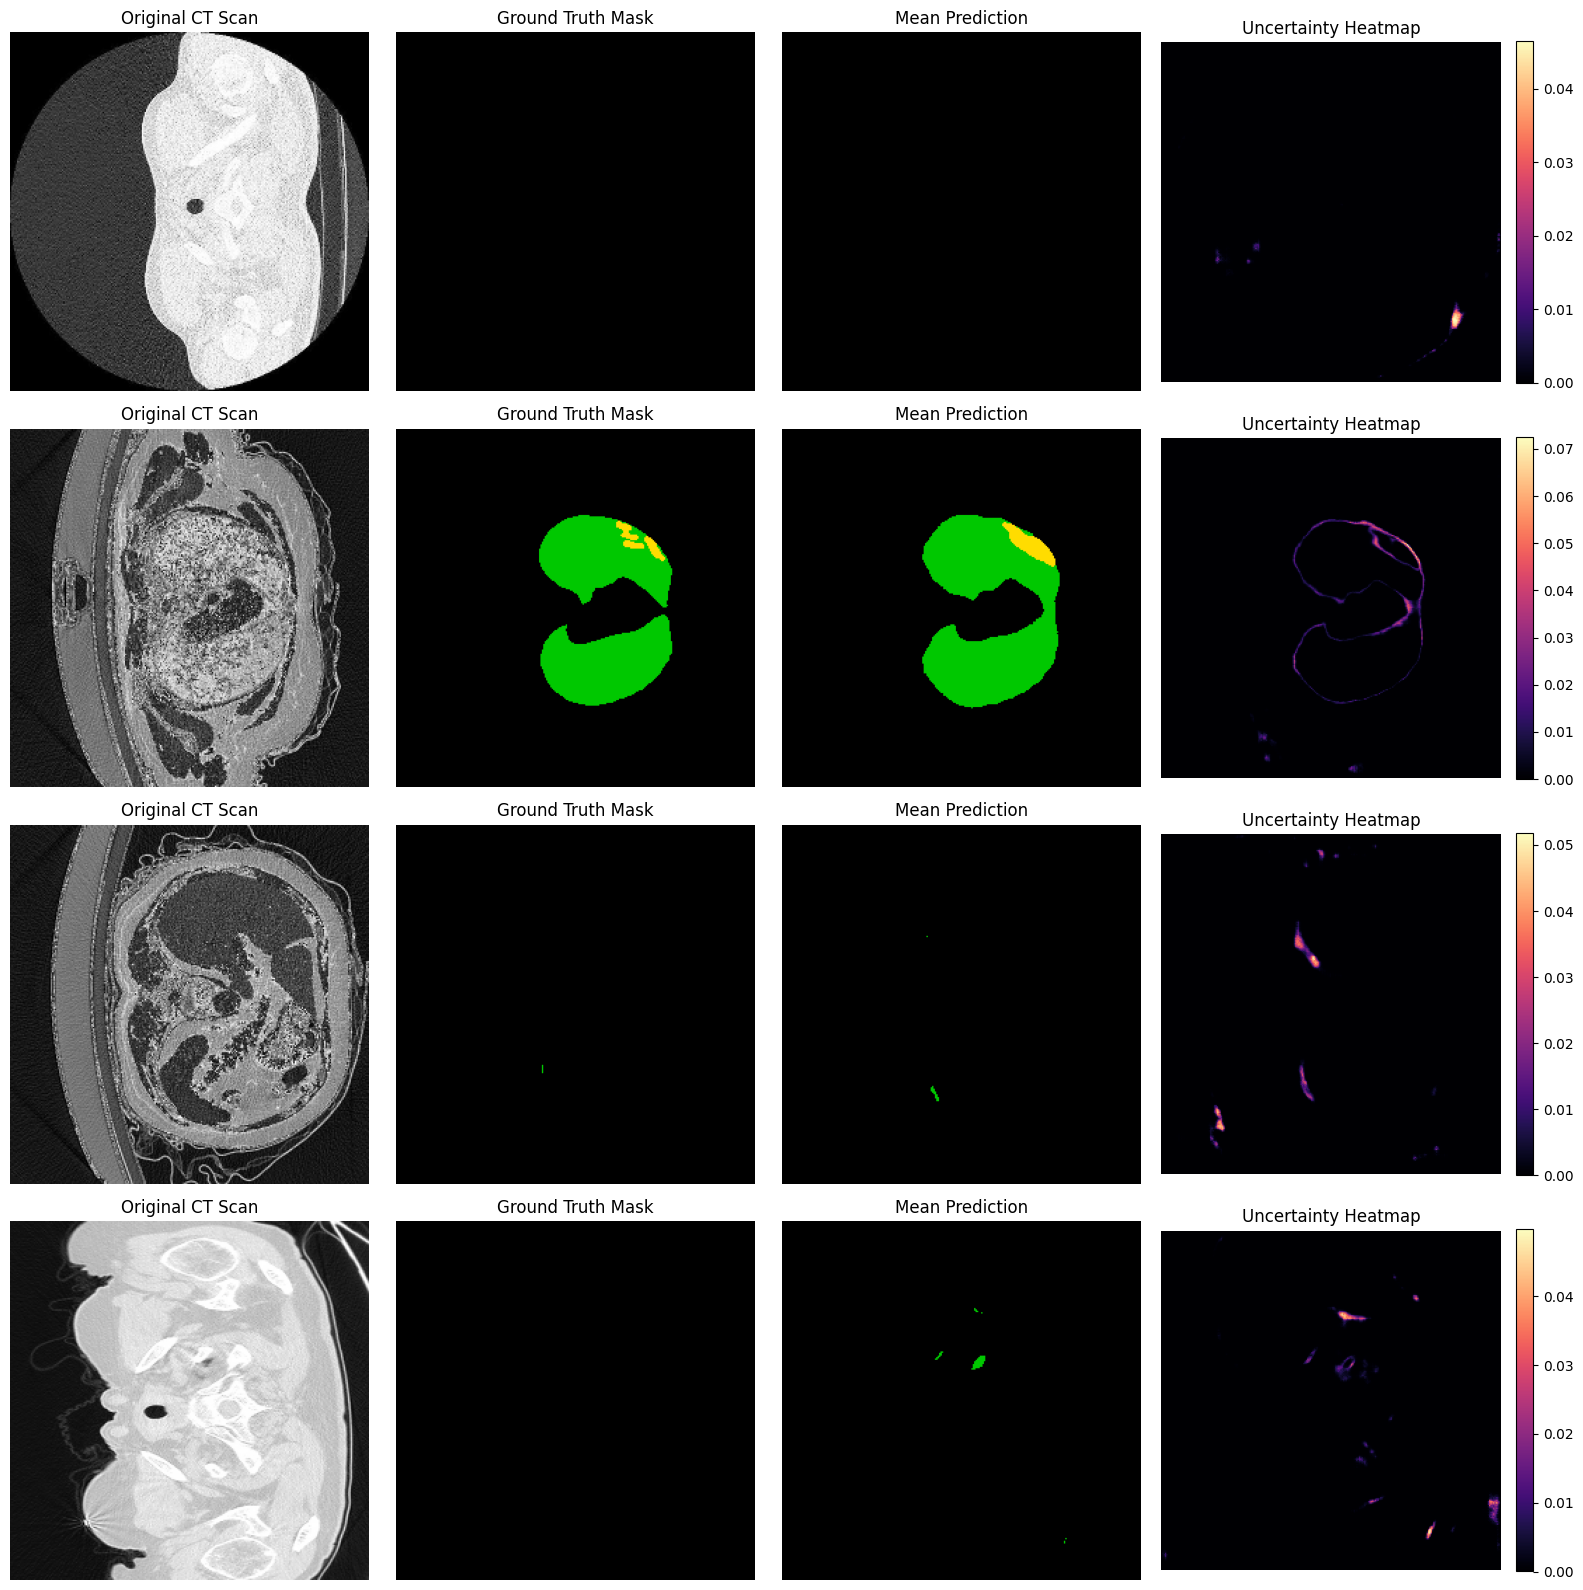

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def generate_uncertainty_maps(model, dataloader, num_images=3, mc_passes=10):
    print(f"Generating predictions using {mc_passes} Monte Carlo passes...")
    
    # Define our custom color map for the 4 classes
    # 0: Black (Background), 1: Green (Lung), 2: Red (Nodule), 3: Yellow (Infection)
    colors = np.array([
        [0, 0, 0],         
        [0, 200, 0],       
        [220, 50, 50],     
        [255, 220, 0]      
    ], dtype=np.uint8)

    # Grab one batch of validation data
    images, true_masks = next(iter(dataloader))
    images = images.to(device)
    
    # --- The Magic Method ---
    # This calls the custom function we built into your architecture
    mean_probs, uncertainty_map = model.predict_with_uncertainty(images, num_passes=mc_passes)
    
    # Convert mean probabilities to final class predictions
    predictions = torch.argmax(mean_probs, dim=1)
    
    # Move everything to CPU for plotting
    images = images.cpu().numpy()
    true_masks = true_masks.cpu().numpy()
    predictions = predictions.cpu().numpy()
    uncertainty_map = uncertainty_map.cpu().numpy()
    
    # --- Plotting ---
    fig, axes = plt.subplots(num_images, 4, figsize=(16, 4 * num_images))
    if num_images == 1: axes = [axes]
        
    for i in range(min(num_images, images.shape[0])):
        img = images[i, 0] # Grayscale CT
        
        # Colorize masks
        true_color = colors[true_masks[i]]
        pred_color = colors[predictions[i]]
        
        # 1. Original CT
        axes[i][0].imshow(img, cmap='gray')
        axes[i][0].set_title("Original CT Scan", fontsize=12)
        axes[i][0].axis('off')
        
        # 2. Ground Truth
        axes[i][1].imshow(true_color)
        axes[i][1].set_title("Ground Truth Mask", fontsize=12)
        axes[i][1].axis('off')
        
        # 3. Model Prediction
        axes[i][2].imshow(pred_color)
        axes[i][2].set_title("Mean Prediction", fontsize=12)
        axes[i][2].axis('off')
        
        # 4. Uncertainty Heatmap
        # We use the 'magma' colormap: Dark = Certain, Bright Yellow/White = Highly Uncertain
        im = axes[i][3].imshow(uncertainty_map[i], cmap='magma')
        axes[i][3].set_title("Uncertainty Heatmap", fontsize=12)
        axes[i][3].axis('off')
        
        # Add a subtle colorbar to the heatmap
        fig.colorbar(im, ax=axes[i][3], fraction=0.046, pad=0.04)
        
    plt.tight_layout()
    plt.show()



model.load_state_dict(torch.load('best_robust_lung_model.pth'))

generate_uncertainty_maps(model, val_loader, num_images=4, mc_passes=10)

# Inferencing

Running on: cpu
Loading model weights...


C:\Users\swara\AppData\Local\Temp\ipykernel_19164\752115853.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=de

Processing image: test_image.png
Running 10 Monte Carlo passes for Uncertainty Estimation...


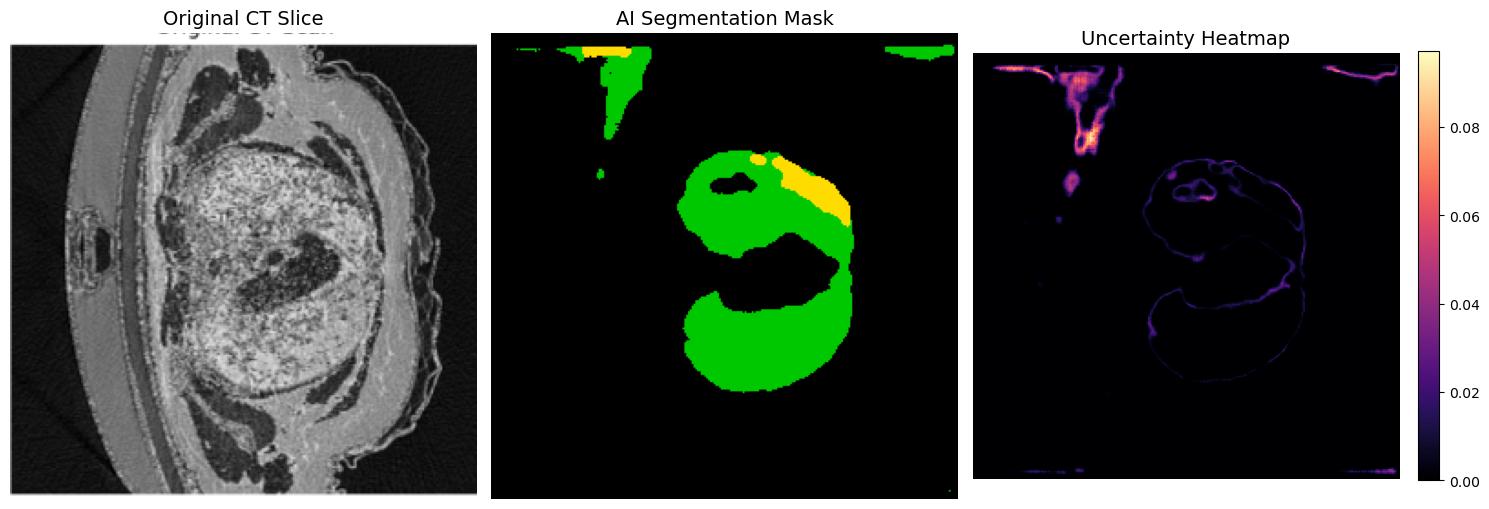

In [10]:
import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt



# 2. PREPROCESSING PIPELINE

def window_and_normalize(image, wl=-600, ww=1500):
    """Applies the exact same CT Lung Window used during training."""
    hu_min = wl - (ww / 2)
    hu_max = wl + (ww / 2)
    image = np.clip(image, hu_min, hu_max)
    return (image - hu_min) / (hu_max - hu_min)

def load_and_preprocess(image_path, target_size=(256, 256)):
    """Loads an image or .npy file and preps it for the neural network."""
    ext = os.path.splitext(image_path)[1].lower()
    
    if ext == '.npy':
        img = np.load(image_path)
    else:
        
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Could not load image at {image_path}")
            
  
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)
    
   
    if img.max() > 255 or img.min() < 0:
        img = window_and_normalize(img)
    else:
        img = img.astype(np.float32) / 255.0
        
   
    img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float()
    
    return img_tensor, img


# 3. INFERENCE & VISUALIZATION

def run_clinical_inference(model_path, image_path, mc_passes=10):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Running on: {device}")
    
    
    print("Loading model weights...")
    model = RobustLungSegNet(num_classes=4).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    
    
    print(f"Processing image: {image_path}")
    img_tensor, original_img_display = load_and_preprocess(image_path)
    img_tensor = img_tensor.to(device)
    
  
    print(f"Running {mc_passes} Monte Carlo passes for Uncertainty Estimation...")
    mean_probs, uncertainty_map = model.predict_with_uncertainty(img_tensor, num_passes=mc_passes)
    
   
    prediction_mask = torch.argmax(mean_probs, dim=1).squeeze().cpu().numpy()
    uncertainty_map = uncertainty_map.squeeze().cpu().numpy()
    

    colors = np.array([
        [0, 0, 0],         
        [0, 200, 0],       
        [220, 50, 50],     
        [255, 220, 0]      
    ], dtype=np.uint8)
    
    pred_color = colors[prediction_mask]
    
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    
    axes[0].imshow(original_img_display, cmap='gray')
    axes[0].set_title("Original CT Slice", fontsize=14)
    axes[0].axis('off')
    
    
    axes[1].imshow(pred_color)
    axes[1].set_title("AI Segmentation Mask", fontsize=14)
    axes[1].axis('off')
    
    
    im = axes[2].imshow(uncertainty_map, cmap='magma')
    axes[2].set_title("Uncertainty Heatmap", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()




if __name__ == "__main__":
  
    MODEL_WEIGHTS = "trained_models/best_robust_lung_model.pth"
    TEST_IMAGE = "test_image.png" 
    
    run_clinical_inference(MODEL_WEIGHTS, TEST_IMAGE)